# ROSSMANN STORE SALES - MODEL IMPLEMENTATION (FIXED)

**Daftar Algoritma:**
1. Linear Regression
2. Artificial Neural Network (ANN)
3. LSTM (Time Series)
4. K-Means Clustering
5. Custom Backpropagation

In [1]:
import os
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Setup Directories
BASE_DIR   = ".."
MODEL_DIR  = os.path.join(BASE_DIR, 'models')
DOCS_DIR   = os.path.join(BASE_DIR, 'docs', '02_model_evaluation')\n
os.makedirs(DOCS_DIR, exist_ok=True)

print("✅ Libraries imported and directories setup successfully.")

✅ Libraries imported and directories setup successfully.


### Load Preprocessed Data

In [2]:
with open(os.path.join(MODEL_DIR, 'preprocessing_data.pkl'), 'rb') as f:
    data = pickle.load(f)

X_train        = data['X_train']
X_test         = data['X_test']
y_train        = data['y_train']
y_test         = data['y_test']
X_train_scaled = data['X_train_scaled']
X_test_scaled  = data['X_test_scaled']

# Split validation for ANN/LSTM
from sklearn.model_selection import train_test_split
X_train_final, X_val_scaled, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

print(f"✅ Data loaded - X_train shape: {X_train.shape}")

✅ Data loaded - X_train shape: (675470, 19)


### 1. Linear Regression

Training Linear Regression...


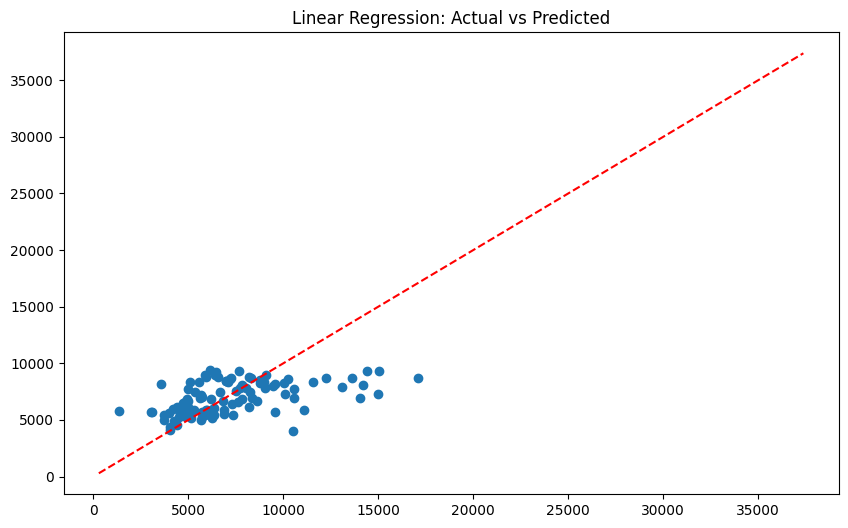

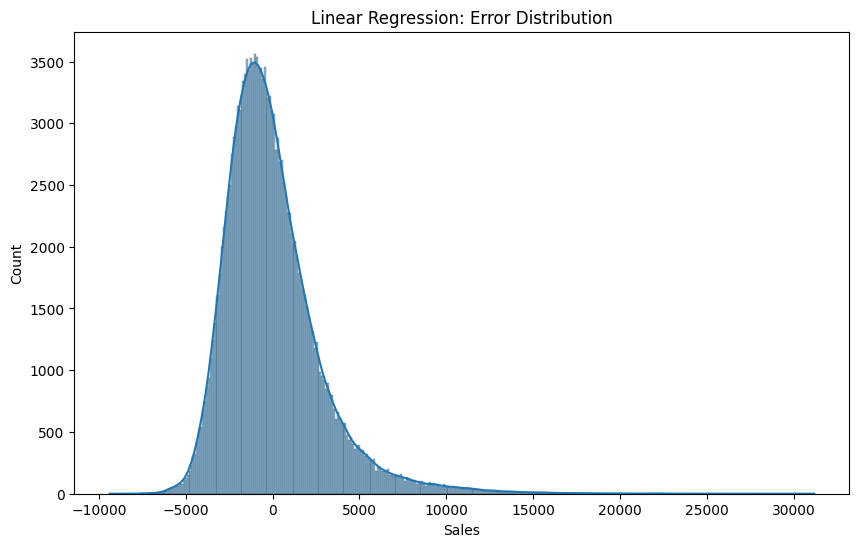

In [7]:
print("Training Linear Regression...")
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)
y_pred = reg.predict(X_test_scaled)

joblib.dump(reg, os.path.join(MODEL_DIR, 'linear_regression_model.pkl'))

# Visualisasi Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test[:100], y_pred[:100])
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression: Actual vs Predicted')
plt.savefig(os.path.join(DOCS_DIR, '01_linear_regression_prediction.png'))
plt.show()

# Visualisasi Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(y_test - y_pred, kde=True)
plt.title('Linear Regression: Error Distribution')
plt.savefig(os.path.join(DOCS_DIR, '01_linear_regression_error.png'))
plt.show()

### 2. Artificial Neural Network (ANN)

Training ANN...
Epoch 1/50
16887/16887 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step - loss: 8955858.0000 - val_loss: 7408099.0000
Epoch 2/50
16887/16887 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 7278968.0000 - val_loss: 7295107.0000
Epoch 3/50
16887/16887 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 7179214.0000 - val_loss: 7203726.5000
Epoch 4/50
16887/16887 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step - loss: 7056894.5000 - val_loss: 7061510.0000
Epoch 5/50
16887/16887 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step - loss: 6908912.5000 - val_loss: 6904013.0000
Epoch 6/50
16887/16887 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 6753196.5000 - val_loss: 6755152.5000
Epoch 7/50
16887/16887 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 6615820.0000 - val_loss: 6620262.0000
Epoch 8/50
16887/16887 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 6476088.5000 - val_loss: 6465216.0000
Epoch 9/50
16887/16887 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 6322814.5000 - val_loss: 6304724.0000
Epoch 10/50
16887/16887 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step

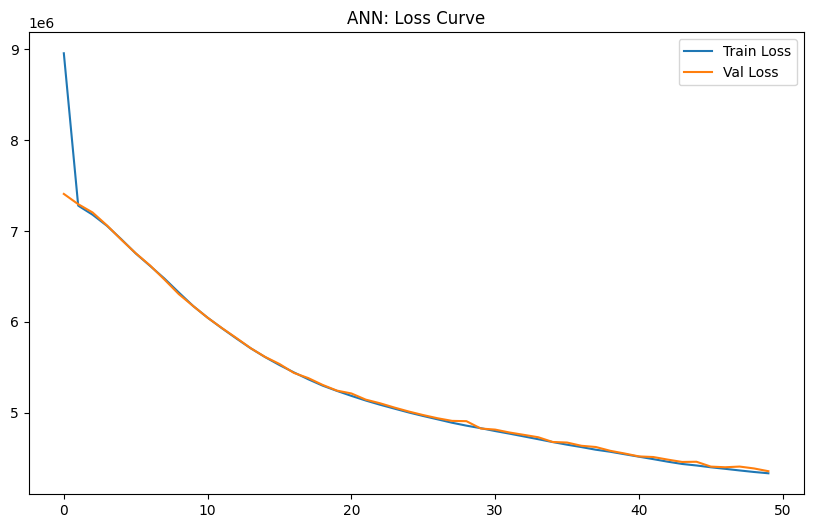

4222/4222 ━━━━━━━━━━━━━━━━━━━━ 3s 659us/step


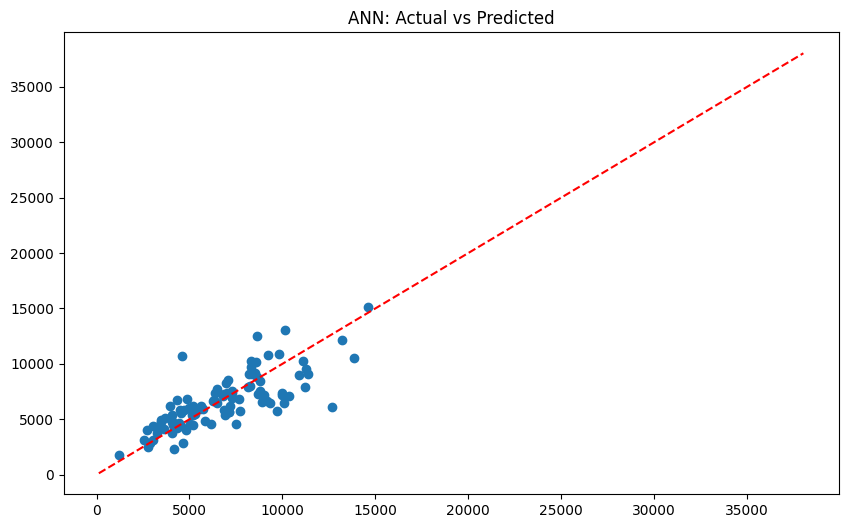

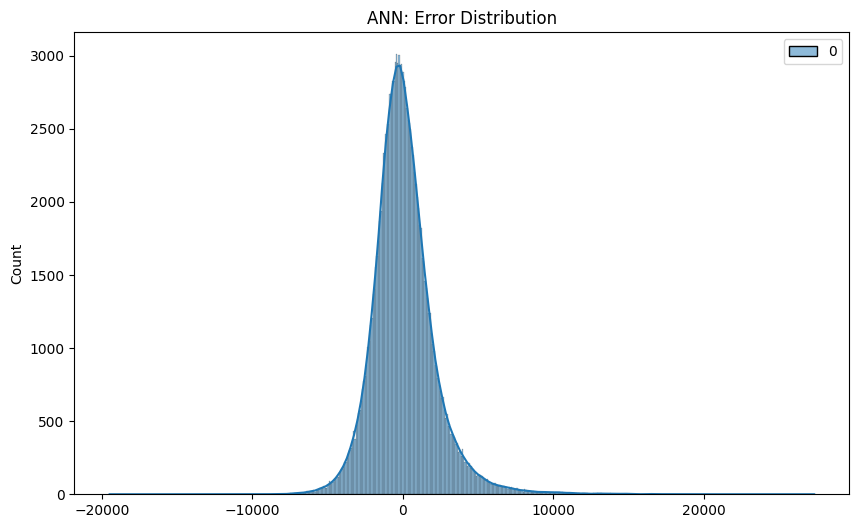

In [4]:
print("Training ANN...")
ann_model = Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

ann_model.compile(optimizer='adam', loss='mse')
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_ann = ann_model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val_scaled, y_val), 
    epochs=50, batch_size=32, verbose=1, 
    callbacks=[early_stop]
)

ann_model.save(os.path.join(MODEL_DIR, 'ann_model.h5'))

# Visualisasi 3 Plot Standar
plt.figure(figsize=(10, 6))
plt.plot(history_ann.history['loss'], label='Train Loss')
plt.plot(history_ann.history['val_loss'], label='Val Loss')
plt.title('ANN: Loss Curve')
plt.legend()
plt.savefig(os.path.join(DOCS_DIR, '04_ann_loss.png'))
plt.show()

y_ann_pred = ann_model.predict(X_val_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(y_val[:100], y_ann_pred[:100])
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.title('ANN: Actual vs Predicted')
plt.savefig(os.path.join(DOCS_DIR, '04_ann_prediction.png'))
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(y_val.values.reshape(-1,1) - y_ann_pred, kde=True)
plt.title('ANN: Error Distribution')
plt.savefig(os.path.join(DOCS_DIR, '04_ann_error.png'))
plt.show()

### 3. LSTM (Time Series)

Loading Time Series data for LSTM...
Training LSTM...
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0670 - val_loss: 0.0329
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0306 - val_loss: 0.0311
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0295 - val_loss: 0.0312
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0293 - val_loss: 0.0319
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0295 - val_loss: 0.0304
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0293 - val_loss: 0.0303
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0296 - val_loss: 0.0306
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0296 - val_loss: 0.0302
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0292 - val_loss: 0.0305
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0296 - val_loss: 0.0327
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0294 - val_loss: 0.0318
Epoch 12/

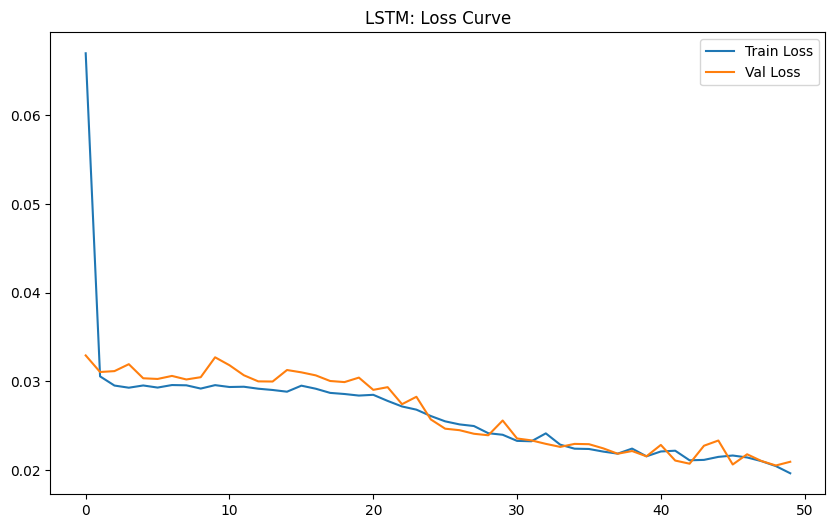

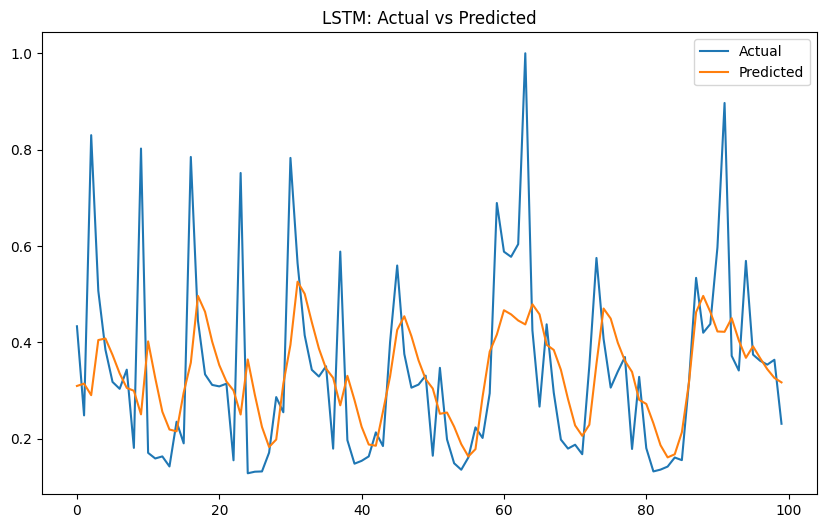

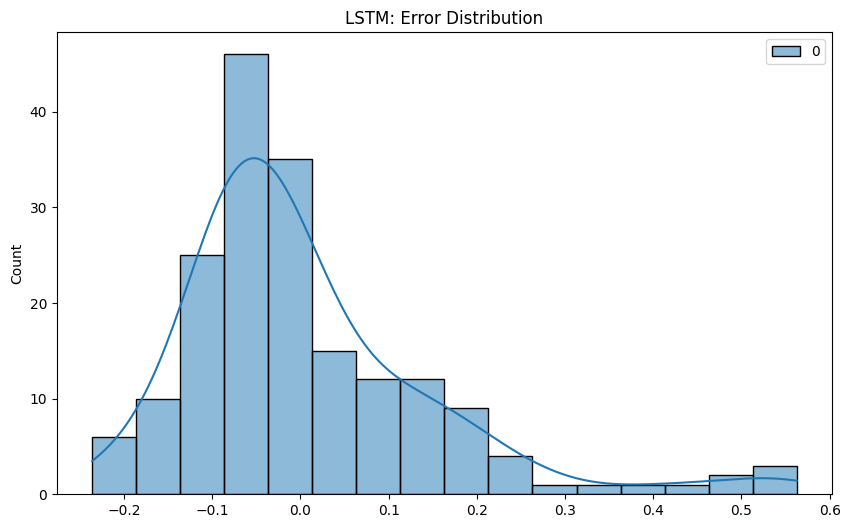

In [8]:
print("Loading Time Series data for LSTM...")
with open(os.path.join(MODEL_DIR, 'timeseries_data.pkl'), 'rb') as f:
    ts_data = pickle.load(f)
daily_sales = ts_data['daily_sales']

scaler_lstm = MinMaxScaler()
sales_norm = scaler_lstm.fit_transform(daily_sales.values.reshape(-1, 1)).flatten()

lookback = 30
X_lstm, y_lstm = [], []
for i in range(lookback, len(sales_norm)):
    X_lstm.append(sales_norm[i-lookback:i])
    y_lstm.append(sales_norm[i])

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)
split = int(len(X_lstm) * 0.8)
X_train_lstm = X_lstm[:split].reshape(-1, lookback, 1)
y_train_lstm = y_lstm[:split]
X_val_lstm   = X_lstm[split:].reshape(-1, lookback, 1)
y_val_lstm   = y_lstm[split:]

print("Training LSTM...")
lstm_model = Sequential([
    layers.Input(shape=(lookback, 1)),
    layers.LSTM(64, activation='relu', return_sequences=True),
    layers.LSTM(32, activation='relu'),
    layers.Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
early_stop_lstm = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train_lstm, y_train_lstm, 
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=50, batch_size=32, verbose=1, 
    callbacks=[early_stop_lstm]
)

lstm_model.save(os.path.join(MODEL_DIR, 'lstm_model.h5'))

# Visualisasi 3 Plot Standar
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM: Loss Curve')
plt.legend()
plt.savefig(os.path.join(DOCS_DIR, '05_lstm_loss.png'))
plt.show()

y_lstm_pred = lstm_model.predict(X_val_lstm, verbose=0)
plt.figure(figsize=(10, 6))
plt.plot(y_val_lstm[:100], label='Actual')
plt.plot(y_lstm_pred[:100], label='Predicted')
plt.title('LSTM: Actual vs Predicted')
plt.legend()
plt.savefig(os.path.join(DOCS_DIR, '05_lstm_prediction.png'))
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(y_val_lstm.reshape(-1,1) - y_lstm_pred, kde=True)
plt.title('LSTM: Error Distribution')
plt.savefig(os.path.join(DOCS_DIR, '05_lstm_error.png'))
plt.show()

### 4. K-Means Clustering

Running K-Means Clustering...


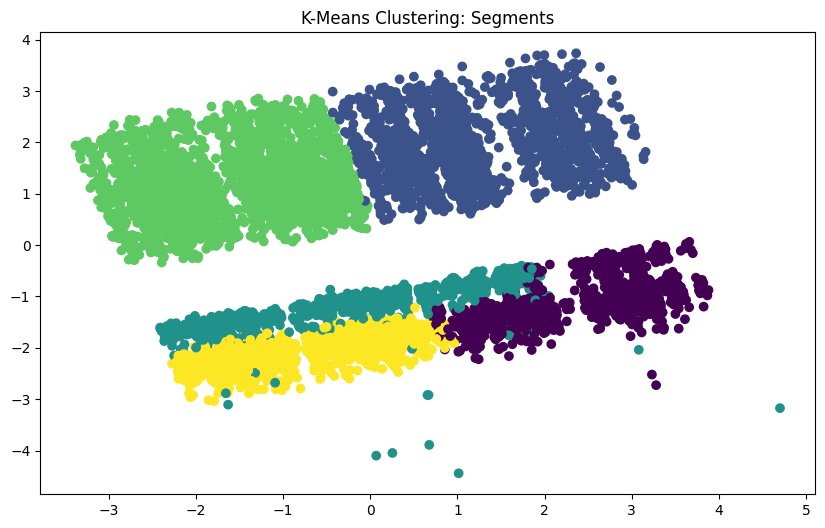

In [9]:
print("Running K-Means Clustering...")
kmeans = KMeans(n_clusters=5, random_state=42)
X_sample = X_train_scaled[:10000]
clusters = kmeans.fit_predict(X_sample)

joblib.dump(kmeans, os.path.join(MODEL_DIR, 'kmeans_model.pkl'))

# Visualisasi Clustering
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title('K-Means Clustering: Segments')
plt.savefig(os.path.join(DOCS_DIR, '06_kmeans_results.png'))
plt.show()

### 5. Custom Backpropagation

Training Custom Backpropagation...
Epoch 10: Loss 57872924.00
Epoch 20: Loss 57861420.00
Epoch 30: Loss 57847868.00


Epoch 40: Loss 57830864.00
Epoch 50: Loss 57808828.00


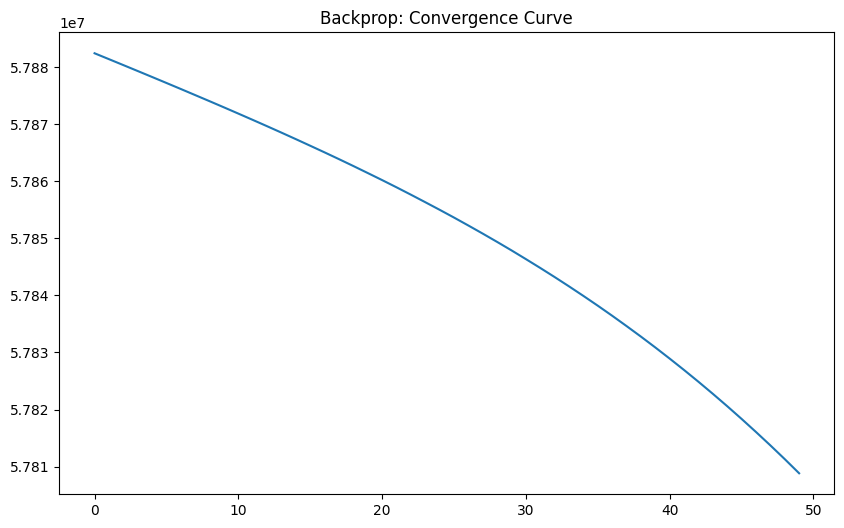

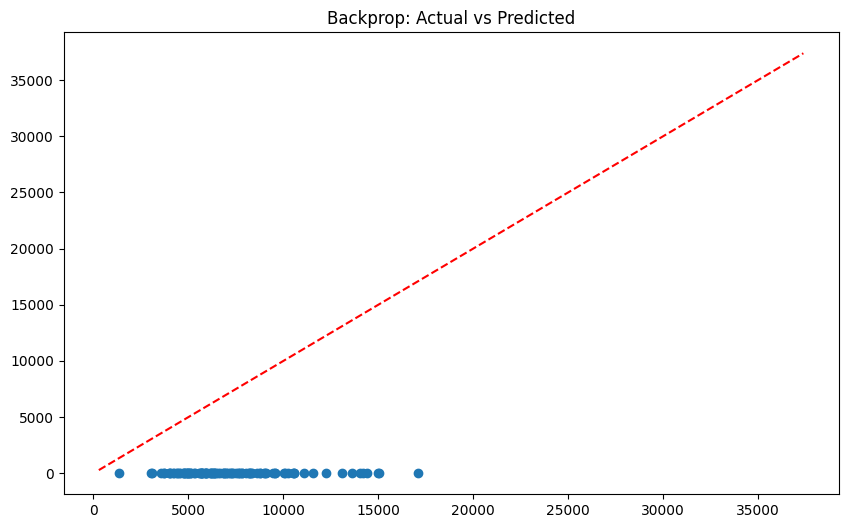

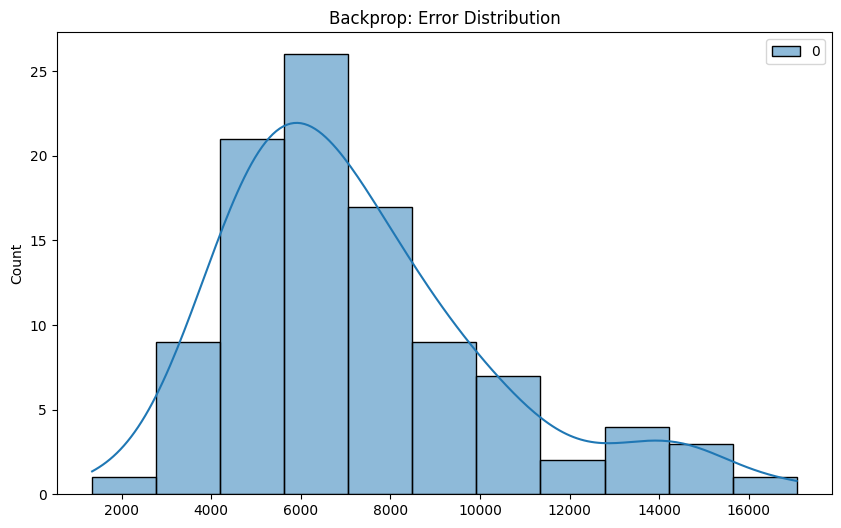

In [10]:
print("Training Custom Backpropagation...")
bp_model = Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam()
loss_fn = tf.keras.losses.MeanSquaredError()

history_bp = []
@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        preds = bp_model(x, training=True)
        loss = loss_fn(y, preds)
    grads = tape.gradient(loss, bp_model.trainable_weights)
    optimizer.apply_gradients(zip(grads, bp_model.trainable_weights))
    return loss

for epoch in range(50):
    l = train_step(tf.constant(X_train_scaled[:50000], dtype=tf.float32), 
                   tf.constant(y_train[:50000].values.reshape(-1, 1), dtype=tf.float32))
    history_bp.append(l.numpy())
    if (epoch+1) % 10 == 0: print(f"Epoch {epoch+1}: Loss {l.numpy():.2f}")

bp_model.save(os.path.join(MODEL_DIR, 'backprop_model.h5'))

# Visualisasi 3 Plot Standar
plt.figure(figsize=(10, 6))
plt.plot(history_bp)
plt.title('Backprop: Convergence Curve')
plt.savefig(os.path.join(DOCS_DIR, '07_backprop_loss.png'))
plt.show()

y_bp_pred = bp_model.predict(tf.constant(X_test_scaled[:100], dtype=tf.float32), verbose=0)
plt.figure(figsize=(10, 6))
plt.scatter(y_test[:100], y_bp_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Backprop: Actual vs Predicted')
plt.savefig(os.path.join(DOCS_DIR, '07_backprop_prediction.png'))
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(y_test[:100].values.reshape(-1,1) - y_bp_pred, kde=True)
plt.title('Backprop: Error Distribution')
plt.savefig(os.path.join(DOCS_DIR, '07_backprop_error.png'))
plt.show()